In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Columns in dataset:\n", df.columns)
df.head()


Columns in dataset:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Data Cleaning


In [11]:
# Step 1: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill missing values using median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())



In [12]:
df['TotalCharges'].dtype
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Exploratory Data Analysis

Churn Distribution

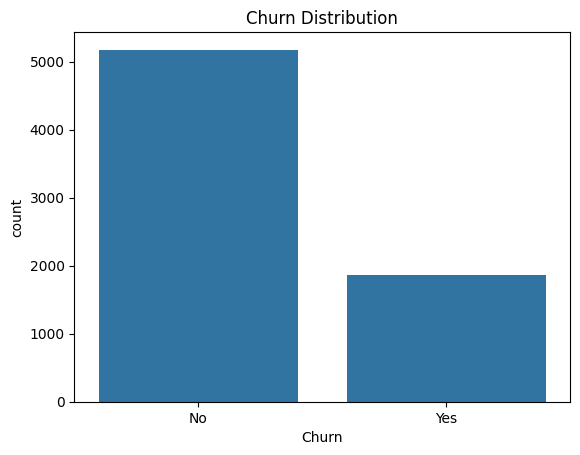

In [13]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


Churn Vs Contract


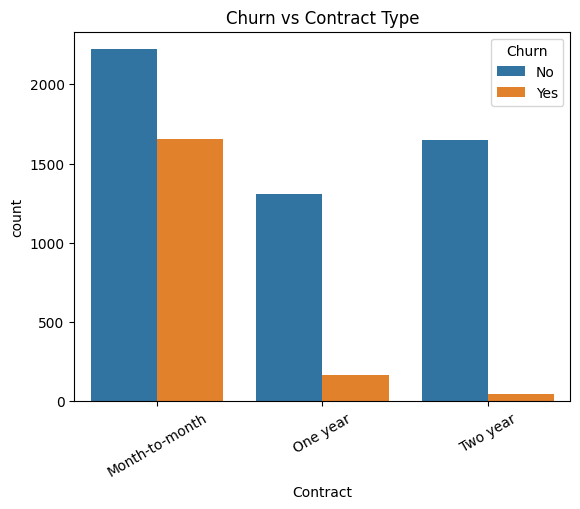

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn vs Contract Type")
plt.xticks(rotation=30)
plt.show()


Churn vs Monthly Charges

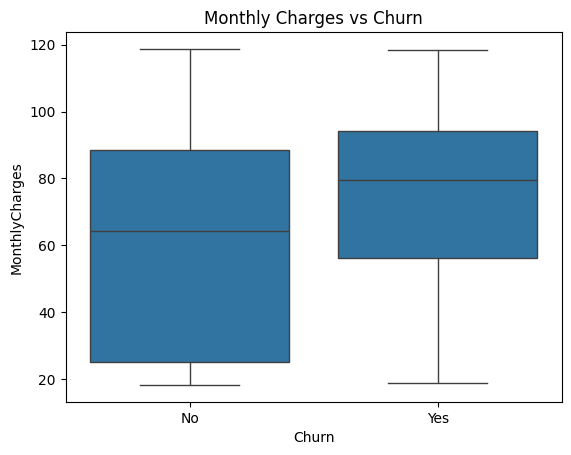

In [20]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()



Churn vs Tenure

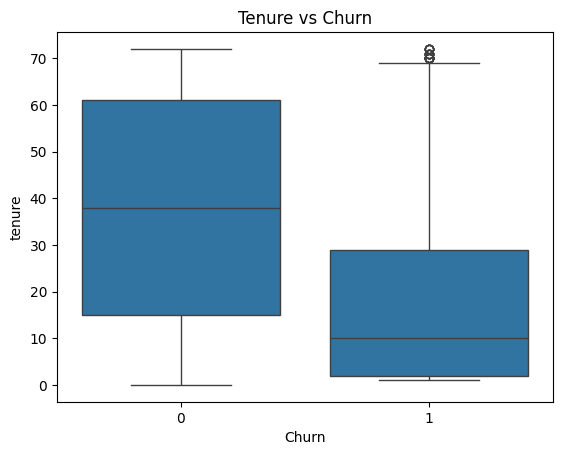

In [55]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


FEATURE ENGINEERING & ENCODING

Drop customerID

In [56]:
df.drop('customerID', axis=1, inplace=True)


KeyError: "['customerID'] not found in axis"

Encode Target Variable

In [21]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


One-Hot Encoding

In [24]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [25]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


TRAIN–TEST SPLIT

In [27]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train.shape, X_test.shape


((5634, 30), (1409, 30))

Logistic Regression Model

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(
    max_iter=2000,
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8197303051809794


In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8197303051809794
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



Random Forest Model

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7934705464868701
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Confusion Matrix

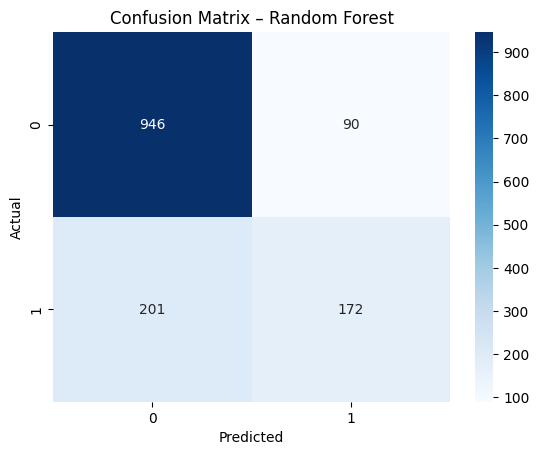

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()


Feature Importance


Feature Importance from Random Forest

In [42]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)


View Top 10 Important Features

In [44]:
feature_importance.head(10)


,Feature,Importance
3,TotalCharges,0.196719
1,tenure,0.170752
2,MonthlyCharges,0.169223
28,PaymentMethod_Electronic check,0.036007
10,InternetService_Fiber optic,0.035989
25,Contract_Two year,0.031140
13,OnlineSecurity_Yes,0.028100
4,gender_Male,0.028045
26,PaperlessBilling_Yes,0.025510
5,Partner_Yes,0.023770


Visualize Feature Importance

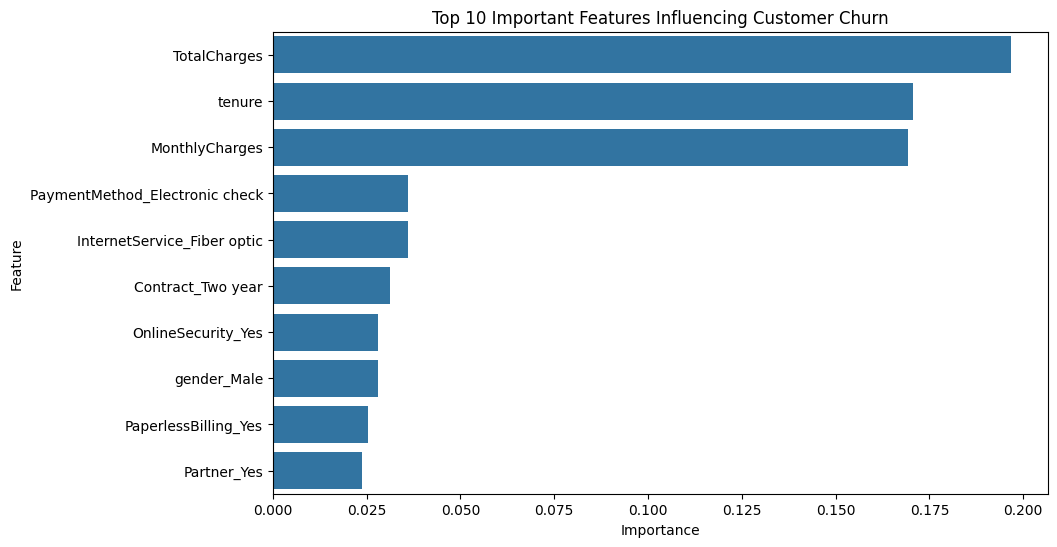

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features Influencing Customer Churn")
plt.show()


Retention Analytics







Predict Churn Probability

In [49]:
churn_prob = rf.predict_proba(X_test)[:, 1]
results = X_test.copy()
results['Actual_Churn'] = y_test.values
results['Churn_Probability'] = churn_prob


Identify High-Risk Customers

Define high risk as probability > 0.6

In [50]:
high_risk_customers = results[results['Churn_Probability'] > 0.6]
high_risk_customers.head()



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability
185,0,1,24.80,24.80,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,1,0.785000
1807,0,1,76.35,76.35,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,1,0.715000
6179,1,11,95.15,997.65,False,False,False,True,False,True,...,False,True,False,False,True,False,False,False,1,0.885000
4640,0,1,70.00,70.00,True,True,True,True,False,False,...,False,False,False,False,True,False,True,False,1,0.849857
3328,0,1,70.25,70.25,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,0,0.930000


Analyze High-Risk Customer Profile

Average Monthly Charges of High-Risk Customers

In [57]:
high_risk_customers['MonthlyCharges'].mean()

np.float64(76.63395721925133)

In [52]:
high_risk_customers['tenure'].mean()


np.float64(7.101604278074866)

Contract Type Analysis


In [53]:
contract_cols = [col for col in results.columns if 'Contract_' in col]
results[contract_cols].mean()


,0
Contract_One year,0.185238
Contract_Two year,0.252661
